### 0.加载数据

In [2]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

sample_data_dir = mne.datasets.sample.data_path()
raw_fname = sample_data_dir / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw.pick(['eeg']) # pick(['eeg']) 不会过滤 info['dig']

# raw.info['dig'] 返回的是 所有通道的 digitization points
dig = raw.info['dig']
# 直接使用文件内自带的电极位置（不需要外部 montage）
# 验证 montage 是否已在位
montage = raw.get_montage()
if montage is None:
    print("⚠️ 无内置 montage，需要手动设置")
else:
    print(f"✅ 内置 montage 已就绪，{len(montage.ch_names)} 个电极")

print("有了 montage（即每个通道都有 3D 坐标）后，MNE 能解锁一大类 空间可视化 功能")


Opening raw data file d:\AI\qwenpaw\eeg_ica_learning\datasets\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
✅ 内置 montage 已就绪，60 个电极
有了 montage（即每个通道都有 3D 坐标）后，MNE 能解锁一大类 空间可视化 功能


### 1.传感器布局图

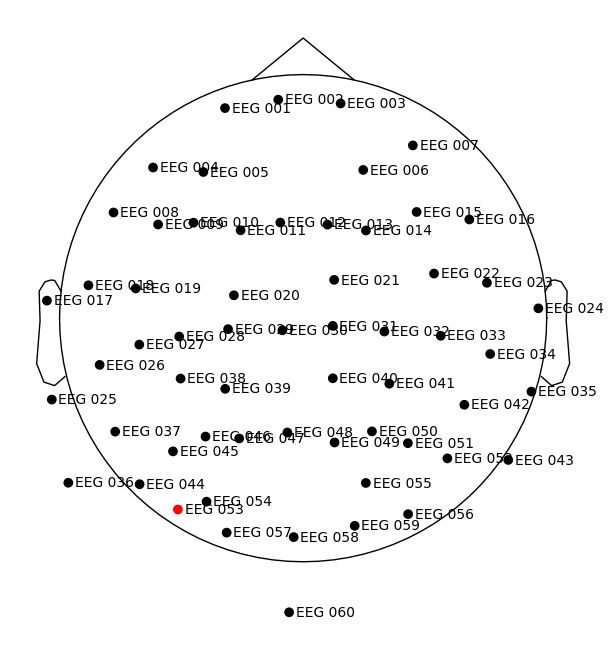

✅ 2D 俯视图（带通道名）已显示


In [3]:
# 2D 俯视图（带通道名）
raw.plot_sensors(show_names=True)
print("✅ 2D 俯视图（带通道名）已显示")


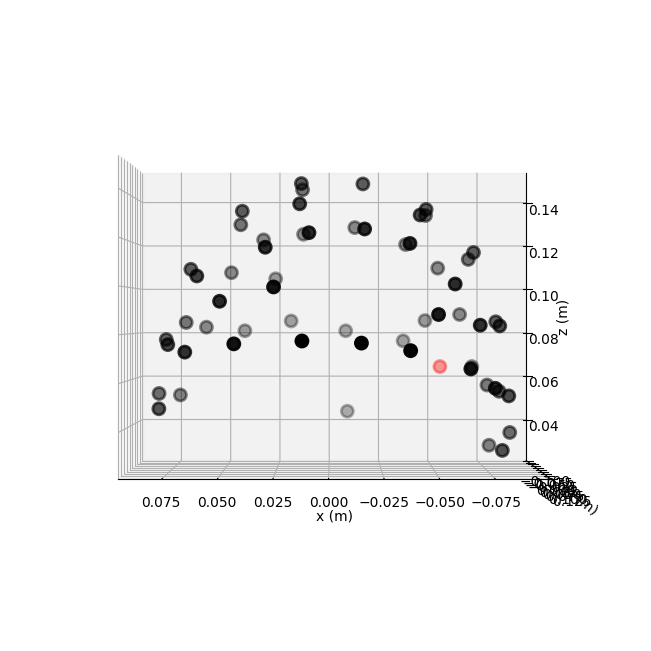

✅ 3D 交互视图（可拖拽旋转）已显示


In [4]:
# 3D 交互视图（可拖拽旋转）
raw.plot_sensors(kind='3d')
print("✅ 3D 交互视图（可拖拽旋转）已显示")


### 2.地形图（Topomap / Topography）—— 最核心

这是 montage 解锁的**最大价值**所在：

| 方法 | 用途 |
|------|------|
| ica.plot_components() | ICA 各成分的头皮分布地形图（判断伪迹的关键！） |
| ica.plot_properties(inst, picks=0) | 单个成分四合一视图（含 topography） |
| evoked.plot_topomap(times=[...]) | ERP 在特定时间点的头皮分布 |
| evoked.plot_joint() | 时间序列 + 地形图联合视图 |
| epochs.plot_psd_topomap() | 各频段的功率谱地形图 |
| raw.plot_psd_topomap() | 原始数据的频段地形图 |





### 3.空间着色

通道按其在头皮的区域（额叶、顶叶、枕叶等）自动分配颜色。



In [1]:
# Butterfly 模式下按空间位置自动着色
# raw.plot(butterfly=True)
# evoked.plot(spatial_colors=True)
print("✅ 空间着色已显示")

✅ 空间着色已显示




### 4.ICA 伪迹识别（你的项目最关键！）

这是你学习项目中 montage 最重要的用途：

```python
ica.plot_components()  # 一眼看出哪个成分是眨眼（前额亮斑）
```

| 伪迹类型 | 在 topomap 上的特征 |
|----------|-------------------|
| 眨眼 | 前额区（Fp1/Fp2）对称强亮斑 |
| 眼动 | 前额区一对相反极性的偶极子 |
| 心跳 | 全头皮低频分布 |
| 肌电 | 颞部局部高频混乱 |





### 5.3D 头皮/脑表面投影

```python
mne.viz.plot_evoked_topomap(evoked, times=[0.1, 0.2], ch_type='eeg')
```





### 🎯 一句话总结

| 没有 montage | 有了 montage |
|-------------|-------------|
| 时域波形、PSD、频谱图 | **以上所有** + 地形图（topomap） |
| ICA 只能看时间序列猜伪迹 | ICA 能看头皮分布**精准识别**伪迹 |
| 只能答"什么时候" | 能答"什么位置" |

对于你的 ICA 伪迹识别学习，montage 几乎是刚需——没有 topomap，眨眼和眼动成分几乎区分不出来。你现在 notebook 里跑完 `ica.fit()` 后直接 `ica.plot_components()` 就能看到最核心的效果了。